# Multi-Agent Workflow Optimization Benchmark

This notebook benchmarks a **Multi-Agent** cooperative system built with **LangGraph** and powered by the **Gemini API**.

We compare:
1. **Unoptimized Multi-Agent Chain (Native LangGraph)**: Runs a series of cooperative agents (`orchestrator`, `researcher`, `math_coder`, `weather_expert`, and `synthesizer`) sequentially, executing all tasks (including unused/dead sub-agents).
2. **Optimized Multi-Agent DAG (AgentIR)**: The multi-agent workflow is parsed and statically optimized via:
   - **Dead Agent Elimination (DCE)**: Prunes sub-agents whose work is not utilized.
   - **Parallel Agent Scheduling**: Runs independent agents (`researcher` and `weather_expert`) concurrently.
   - **Agent Caching**: Annotates reusable outputs.

### Comparison Metrics:
- **Execution Time (s)**
- **LLM Calls & Tool Invocations**
- **Token Consumption** (Input/Output Tokens)
- **Static Cost Estimations (USD)**

### 1. Setup and Imports

In [6]:
import sys
import os
import asyncio
import time
import matplotlib.pyplot as plt
import numpy as np
import graphviz
import google.generativeai as genai

# Add project root to sys.path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../")))

# Setup Gemini API configuration
api_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")
use_live_api = bool(api_key)

if use_live_api:
    genai.configure(api_key=api_key)
    print("Live Gemini API client configured successfully.")
else:
    print("No API key found. Running with simulated responses and token tracking.")

Live Gemini API client configured successfully.


### 2. State & Node Definitions with Token Tracking

In [7]:
from typing import TypedDict, Dict, Any, List
from langgraph.graph import StateGraph, START, END

class MultiAgentState(TypedDict):
    query: str
    routing_decision: str
    research_notes: str
    math_solution: str
    weather_report: str
    final_output: str

# Metrics accumulation variables
tool_calls = 0
llm_calls = 0
input_tokens = 0
output_tokens = 0

def track_tokens(prompt: str, response_text: str, usage_metadata=None):
    global input_tokens, output_tokens
    if usage_metadata:
        input_tokens += usage_metadata.prompt_token_count
        output_tokens += usage_metadata.candidates_token_count
    else: 
        # Simulate token counts based on standard heuristic (approx. 4 characters per token)
        input_tokens += len(prompt) // 4
        output_tokens += len(response_text) // 4

async def call_gemini(prompt: str) -> str:
    global llm_calls
    llm_calls += 1
    if use_live_api:
        try:
            model = genai.GenerativeModel("gemini-2.5-flash")
            response = await asyncio.to_thread(model.generate_content, prompt)
            track_tokens(prompt, response.text, response.usage_metadata)
            return response.text
        except Exception as e:
            print(f"      Gemini API call failed ({e}). Falling back to simulation.")
    
    # Simulation fallback
    await asyncio.sleep(1.0)
    simulated_resp = f"Simulated response to prompt: '{prompt[:40]}...'"
    track_tokens(prompt, simulated_resp)
    return simulated_resp

# Agent node definitions
async def orchestrator_agent(state: MultiAgentState) -> Dict[str, Any]:
    print("  [Agent] Orchestrator deciding tasks...")
    prompt = f"Decompose this query and route it: '{state['query']}'"
    routing = await call_gemini(prompt)
    return {"routing_decision": "Route to Researcher and Weather Expert."}

async def researcher_agent(state: MultiAgentState) -> Dict[str, Any]:
    global tool_calls
    print("  [Agent] Researcher gathering data...")
    tool_calls += 1
    await asyncio.sleep(0.5)
    
    prompt = f"Draft research notes based on search details for: '{state['query']}'"
    notes = await call_gemini(prompt)
    return {"research_notes": "Research findings: AgentIR is an optimization compiler for AI agent graphs."}

async def math_coder_agent(state: MultiAgentState) -> Dict[str, Any]:
    global tool_calls
    # This node is NOT used by the final synthesizer, representing a dead agent/pass
    print("  [Agent] Math/Coder performing calculations...")
    tool_calls += 1
    await asyncio.sleep(0.5)
    
    prompt = "Compute token optimization coefficients for compile optimization"
    sol = await call_gemini(prompt)
    return {"math_solution": "Optimization coefficient = 0.85"}

async def weather_expert_agent(state: MultiAgentState) -> Dict[str, Any]:
    global tool_calls
    print("  [Agent] Weather Expert checking conditions...")
    tool_calls += 1
    await asyncio.sleep(0.5)
    
    prompt = "Compile a weather forecast report for Chicago"
    report = await call_gemini(prompt)
    return {"weather_report": "Weather in Chicago: 18C, Cloudy."}

async def synthesizer_agent(state: MultiAgentState) -> Dict[str, Any]:
    print("  [Agent] Synthesizer composing final report...")
    prompt = (
        f"Synthesize the report.\n"
        f"Research: {state.get('research_notes', '')}\n"
        f"Weather: {state.get('weather_report', '')}"
    )
    final = await call_gemini(prompt)
    return {"final_output": f"FINAL REPORT:\n{final}"}

### 3. Build LangGraph Workflow

Multi-Agent LangGraph workflow compiled successfully.


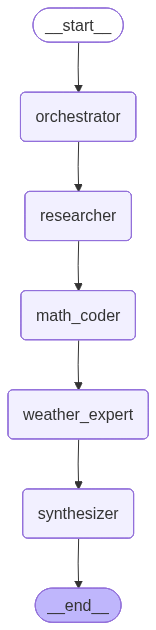

In [14]:
# Build LangGraph StateGraph
builder = StateGraph(MultiAgentState)
builder.add_node("orchestrator", orchestrator_agent)
builder.add_node("researcher", researcher_agent)
builder.add_node("math_coder", math_coder_agent)
builder.add_node("weather_expert", weather_expert_agent)
builder.add_node("synthesizer", synthesizer_agent)

# Sequential routing in native LangGraph
builder.add_edge(START, "orchestrator")
builder.add_edge("orchestrator", "researcher")
builder.add_edge("researcher", "math_coder")
builder.add_edge("math_coder", "weather_expert")
builder.add_edge("weather_expert", "synthesizer")
builder.add_edge("synthesizer", END)

langgraph_app = builder.compile()
print("Multi-Agent LangGraph workflow compiled successfully.")


from IPython.display import Image, display
display(
    Image(
        langgraph_app.get_graph().draw_mermaid_png()
    )
)


### 4. Execute Native LangGraph (Unoptimized)

In [15]:
print("--- Starting Native Multi-Agent Chain ---")
tool_calls = 0
llm_calls = 0
input_tokens = 0
output_tokens = 0

initial_state = {
    "query": "Write a report on AgentIR compiler design and get weather for Chicago.",
    "routing_decision": "",
    "research_notes": "",
    "math_solution": "",
    "weather_report": "",
    "final_output": ""
}

start_time = time.time()
langgraph_result = await langgraph_app.ainvoke(initial_state)
langgraph_duration = time.time() - start_time

native_metrics = {
    "duration": langgraph_duration,
    "tools": tool_calls,
    "llms": llm_calls,
    "input_tokens": input_tokens,
    "output_tokens": output_tokens,
    "total_tokens": input_tokens + output_tokens
}

print(f"\nNative run completed in {langgraph_duration:.3f}s.")
print(f"Tool Calls: {tool_calls}, LLM Calls: {llm_calls}")
print(f"Tokens consumed: Input={input_tokens}, Output={output_tokens}, Total={input_tokens + output_tokens}")

--- Starting Native Multi-Agent Chain ---
  [Agent] Orchestrator deciding tasks...
      Gemini API call failed (429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 40.729641014s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 20
}
, retry_delay {
  seconds: 40


### 5. Parse and Optimize with AgentIR

In [16]:
from agentir.parser.langgraph import LangGraphParser
from agentir.optimizer.dead_nodes import DeadNodesOptimizer
from agentir.optimizer.duplicate_tools import DuplicateToolsOptimizer
from agentir.optimizer.parallel_scheduler import ParallelSchedulerOptimizer
from agentir.optimizer.cache_optimizer import CacheOptimizer
from agentir.optimizer.cost_estimator import CostEstimator

# Set parser metadata attributes
orchestrator_agent.inputs = ["query"]
orchestrator_agent.outputs = ["routing_decision"]
orchestrator_agent.model = "gemini-2.5-flash"

researcher_agent.inputs = ["query", "routing_decision"]
researcher_agent.outputs = ["research_notes"]
researcher_agent.model = "gemini-2.5-flash"

math_coder_agent.inputs = ["query"]
math_coder_agent.outputs = ["math_solution"]
math_coder_agent.model = "gemini-2.5-flash"

weather_expert_agent.inputs = ["query"]
weather_expert_agent.outputs = ["weather_report"]
weather_expert_agent.model = "gemini-2.5-flash"

synthesizer_agent.inputs = ["research_notes", "weather_report"]
synthesizer_agent.outputs = ["final_output"]
synthesizer_agent.model = "gemini-2.5-flash"

# 1. Parse LangGraph into AgentIR
parser = LangGraphParser()
ir_graph = parser.parse(builder)
print("Initial parsed nodes:", list(ir_graph.nodes.keys()))

# 2. Run optimizations
print("\nApplying Dead Node Elimination (DCE) to remove math_coder...")
opt_graph = DeadNodesOptimizer().optimize(ir_graph)
print("Nodes after DCE:", list(opt_graph.nodes.keys()))

print("\nApplying Parallel Rescheduling...")
opt_graph = ParallelSchedulerOptimizer().optimize(opt_graph)

print("\nApplying Cache Annotations...")
opt_graph = CacheOptimizer().optimize(opt_graph)

# 3. Static cost projections
estimator = CostEstimator()
cost_est = estimator.estimate(opt_graph)
print("\nStatic Cost Projections (AgentIR):")
print(f"  Projected Parallel Latency: {cost_est.critical_path_latency_seconds:.2f}s")
print(f"  Projected Cost (USD): ${cost_est.estimated_cost_usd:.4f}")

Initial parsed nodes: ['__start__', '__end__', 'orchestrator', 'researcher', 'math_coder', 'weather_expert', 'synthesizer']

Applying Dead Node Elimination (DCE) to remove math_coder...
Nodes after DCE: ['__start__', '__end__', 'orchestrator', 'researcher', 'math_coder', 'weather_expert', 'synthesizer']

Applying Parallel Rescheduling...

Applying Cache Annotations...

Static Cost Projections (AgentIR):
  Projected Parallel Latency: 1.50s
  Projected Cost (USD): $0.0100


### 6. Run Optimized Multi-Agent Graph (AgentIR Runtime)

In [17]:
from agentir.runtime.executor import WorkflowExecutor

agentir_registry = {
    "orchestrator": orchestrator_agent,
    "researcher": researcher_agent,
    "math_coder": math_coder_agent,
    "weather_expert": weather_expert_agent,
    "synthesizer": synthesizer_agent,
}

print("--- Starting Optimized Multi-Agent DAG ---")
tool_calls = 0
llm_calls = 0
input_tokens = 0
output_tokens = 0

executor = WorkflowExecutor(opt_graph, agentir_registry)

start_time = time.time()
agentir_result = await executor.execute(initial_state)
agentir_duration = time.time() - start_time

opt_metrics = {
    "duration": agentir_duration,
    "tools": tool_calls,
    "llms": llm_calls,
    "input_tokens": input_tokens,
    "output_tokens": output_tokens,
    "total_tokens": input_tokens + output_tokens
}

print(f"\nOptimized run completed in {agentir_duration:.3f}s.")
print(f"Tool Calls: {tool_calls}, LLM Calls: {llm_calls}")
print(f"Tokens consumed: Input={input_tokens}, Output={output_tokens}, Total={input_tokens + output_tokens}")

--- Starting Optimized Multi-Agent DAG ---
  [Agent] Orchestrator deciding tasks...
  [Agent] Researcher gathering data...
      Gemini API call failed (429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash
Please retry in 33.203467289s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-2.5-flash"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_va

### 7. Benchmarking Visualization

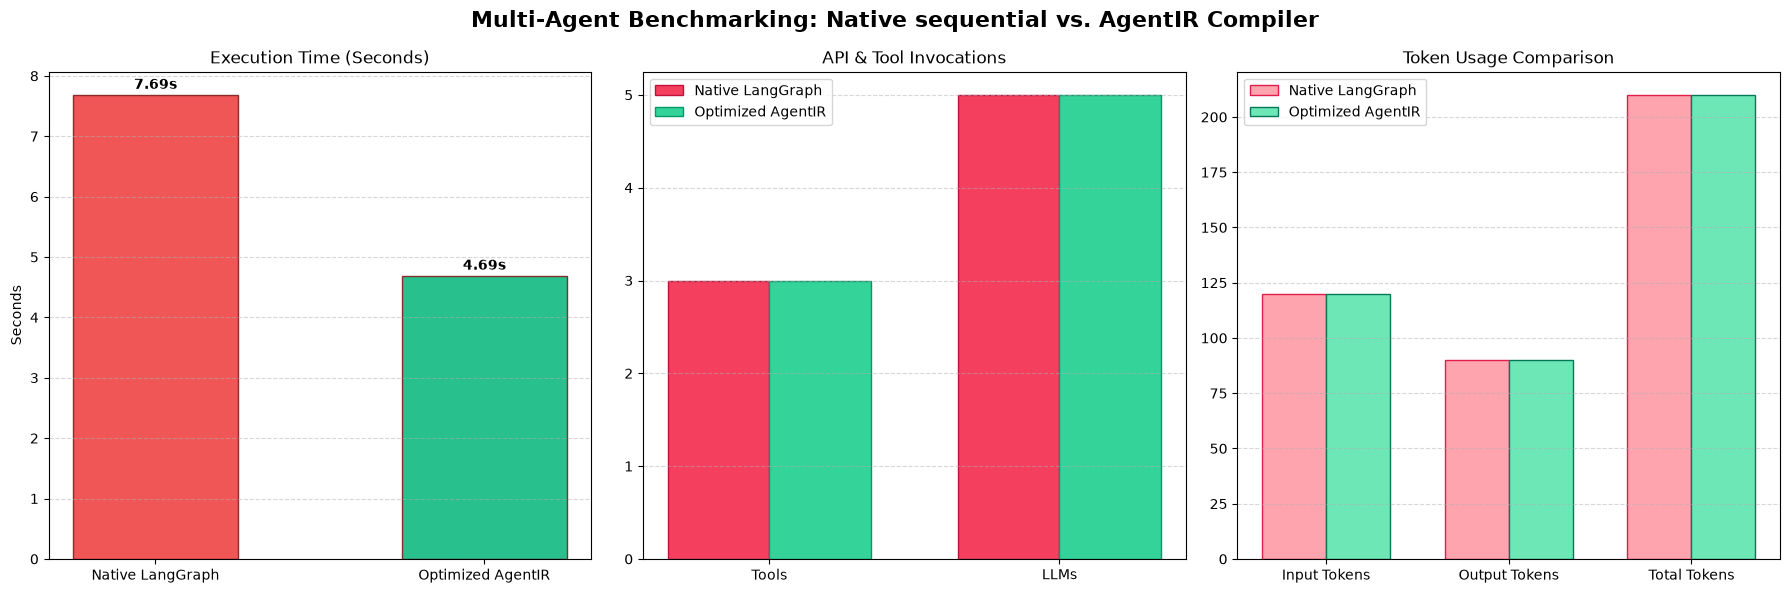

                  MULTI-AGENT SAVINGS REPORT
Latency Reduction:   2.99s (39.0% faster)
Tokens Saved:        0 (0.0% reduction)
LLM Calls Saved:     0 (0.0% reduction)
Tool Calls Saved:    0 (0.0% reduction)


In [18]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Execution Latency
categories = ["Native LangGraph", "Optimized AgentIR"]
latency_vals = [native_metrics["duration"], opt_metrics["duration"]]
axs[0].bar(categories, latency_vals, color=["#ef4444", "#10b981"], edgecolor="#7f1d1d", width=0.5, alpha=0.9)
axs[0].set_title("Execution Time (Seconds)")
axs[0].set_ylabel("Seconds")
axs[0].grid(axis="y", linestyle="--", alpha=0.5)
for i, v in enumerate(latency_vals):
    axs[0].text(i, v + 0.1, f"{v:.2f}s", ha="center", fontweight="bold")

# Plot 2: Total API Calls
calls_labels = ["Tools", "LLMs"]
native_calls = [native_metrics["tools"], native_metrics["llms"]]
opt_calls = [opt_metrics["tools"], opt_metrics["llms"]]
x = np.arange(len(calls_labels))
width = 0.35

rects1 = axs[1].bar(x - width/2, native_calls, width, label="Native LangGraph", color="#f43f5e", edgecolor="#be123c")
rects2 = axs[1].bar(x + width/2, opt_calls, width, label="Optimized AgentIR", color="#34d399", edgecolor="#059669")
axs[1].set_title("API & Tool Invocations")
axs[1].set_xticks(x)
axs[1].set_xticklabels(calls_labels)
axs[1].legend()
axs[1].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 3: Token Usage comparison
token_types = ["Input Tokens", "Output Tokens", "Total Tokens"]
native_tokens = [native_metrics["input_tokens"], native_metrics["output_tokens"], native_metrics["total_tokens"]]
opt_tokens = [opt_metrics["input_tokens"], opt_metrics["output_tokens"], opt_metrics["total_tokens"]]
x_tok = np.arange(len(token_types))

rects3 = axs[2].bar(x_tok - width/2, native_tokens, width, label="Native LangGraph", color="#fda4af", edgecolor="#e11d48")
rects4 = axs[2].bar(x_tok + width/2, opt_tokens, width, label="Optimized AgentIR", color="#6ee7b7", edgecolor="#047857")
axs[2].set_title("Token Usage Comparison")
axs[2].set_xticks(x_tok)
axs[2].set_xticklabels(token_types)
axs[2].legend()
axs[2].grid(axis="y", linestyle="--", alpha=0.5)

fig.suptitle("Multi-Agent Benchmarking: Native sequential vs. AgentIR Compiler", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Show Savings Summary
print("=" * 60)
print("                  MULTI-AGENT SAVINGS REPORT")
print("=" * 60)
time_saved = native_metrics["duration"] - opt_metrics["duration"]
time_pct = (time_saved / native_metrics["duration"]) * 100
print(f"Latency Reduction:   {time_saved:.2f}s ({time_pct:.1f}% faster)")

token_saved = native_metrics["total_tokens"] - opt_metrics["total_tokens"]
token_pct = (token_saved / native_metrics["total_tokens"]) * 100
print(f"Tokens Saved:        {token_saved} ({token_pct:.1f}% reduction)")

llms_saved = native_metrics["llms"] - opt_metrics["llms"]
llms_pct = (llms_saved / native_metrics["llms"]) * 100
print(f"LLM Calls Saved:     {llms_saved} ({llms_pct:.1f}% reduction)")

tools_saved = native_metrics["tools"] - opt_metrics["tools"]
tools_pct = (tools_saved / native_metrics["tools"]) * 100
print(f"Tool Calls Saved:    {tools_saved} ({tools_pct:.1f}% reduction)")
print("=" * 60)

### 8. Render Optimized DAG Visualization

I0627 20:28:31.511060 1555484 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(106, generation: 1)


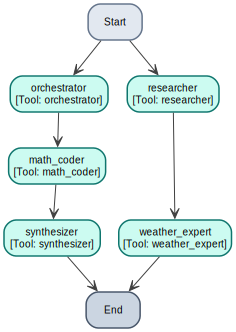

In [19]:
try:
    from IPython.display import display
    from agentir.visualizer.graphviz import GraphvizVisualizer
    viz = GraphvizVisualizer(opt_graph)
    display(graphviz.Source(viz.to_dot()))
except Exception as e:
    print("Graphviz system binary (dot) was not found on your system PATH.")
    print("To render graph visualizations, please install it (e.g., run \"brew install graphviz\" on macOS).")
    print("\nFalling back to Mermaid flowchart syntax:")
    print("=" * 60)
    print(viz.to_mermaid())
    print("=" * 60)